# Guardian Insurance Case Study - EDA

Standard EDA workflow for the Road Risk and Claim Assessment case study.

In [1]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Define the dataset path
file_path = '/content/drive/MyDrive/SDA/guardian-insurance-data.csv'

# Load the dataset
df = pd.read_csv(file_path,low_memory=False)

## Data Understanding

In [4]:
# Display the number of rows and columns
df.shape

(1592049, 47)

In [5]:
# Display the first five rows
df.head()

,Unnamed: 0,Record_ID,Data_Source,Severity,Incident_Start,Incident_End,Lat_Begin,Lng_Begin,Lat_End,Lng_End,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,0,A-5818077,Source1,2.0,2021-06-14 17:02:00,2021-06-14 19:54:17,36.733629,-119.499021,36.733546,-119.497865,...,False,False,False,False,False,False,Day,Day,Day,Day
1,1,A-4539851,Source1,2.0,2022-04-15 14:20:00.000000000,2022-04-15 17:49:03.000000000,37.836539,-122.011617,37.848049,-122.027707,...,False,False,False,False,False,False,Day,Day,Day,Day
2,2,A-1264030,Source2,3.0,2020-11-16 18:11:22,2020-11-16 19:27:18,35.591496,-82.568298,NaN,NaN,...,False,False,False,False,False,False,Night,Night,Day,Day
3,3,A-5187515,Source1,2.0,2022-09-04 10:25:00,2022-09-04 11:44:00,38.797457,-121.882040,38.796722,-121.881355,...,False,False,False,False,False,False,Day,Day,Day,Day
4,4,A-1808663,Source3,2.0,2019-11-08 06:05:40,2019-11-08 07:05:28,37.776779,-122.236168,NaN,NaN,...,False,False,False,False,False,False,Night,Night,Day,Day


In [6]:
# Display all column names
df.columns.tolist()

['Unnamed: 0',
 'Record_ID',
 'Data_Source',
 'Severity',
 'Incident_Start',
 'Incident_End',
 'Lat_Begin',
 'Lng_Begin',
 'Lat_End',
 'Lng_End',
 'Distance(mi)',
 'Event_Summary',
 'Street_name',
 'City_name',
 'County',
 'State',
 'Postal_ID',
 'Country_name',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Temp(F)',
 'WindChill(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Direction',
 'Wind_Speed(mph)',
 'Precipitation(in)',
 'Weather_Condition',
 'Amenity',
 'Bump',
 'Crossing',
 'Give_Way',
 'Road_Junction',
 'Dead_End',
 'Railway',
 'Roundabout',
 'Station',
 'Stop',
 'Traffic_Calming',
 'Traffic_Signal',
 'Turning_Loop',
 'Sunrise_Sunset',
 'Civil_Twilight',
 'Nautical_Twilight',
 'Astronomical_Twilight']

In [7]:
# Display dataset information, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1592049 entries, 0 to 1592048
Data columns (total 47 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1592049 non-null  int64  
 1   Record_ID              1592049 non-null  object 
 2   Data_Source            1512497 non-null  object 
 3   Severity               1512497 non-null  float64
 4   Incident_Start         1592049 non-null  object 
 5   Incident_End           1592049 non-null  object 
 6   Lat_Begin              1512497 non-null  float64
 7   Lng_Begin              1512497 non-null  float64
 8   Lat_End                847157 non-null   float64
 9   Lng_End                847157 non-null   float64
 10  Distance(mi)           1512497 non-null  float64
 11  Event_Summary          1512497 non-null  object 
 12  Street_name            1510309 non-null  object 
 13  City_name              1512444 non-null  object 
 14  County            

In [8]:
# Display descriptive statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1592049.0,796024.000000,459585.103693,0.000000,398012.000000,796024.000000,1.194036e+06,1.592048e+06
Severity,1512497.0,2.212151,0.487179,1.000000,2.000000,2.000000,2.000000e+00,4.000000e+00
Lat_Begin,1512497.0,36.204481,5.074255,24.559731,33.409885,35.830070,4.008358e+01,4.900050e+01
Lng_Begin,1512497.0,-94.709628,17.398673,-124.623833,-117.226315,-87.760316,-8.035168e+01,-6.778734e+01
Lat_End,847157.0,36.265493,5.274177,24.570107,33.462212,36.201433,4.017846e+01,4.900077e+01
Lng_End,847157.0,-95.732230,18.115932,-124.543727,-117.773482,-88.029964,-8.024355e+01,-6.778734e+01
Distance(mi),1512497.0,0.562511,1.807258,0.000000,0.000000,0.030000,4.650000e-01,4.417500e+02
Temp(F),1480396.0,61.677486,19.005454,-89.000000,49.000000,64.000000,7.600000e+01,1.960000e+02
WindChill(F),1121579.0,58.265558,22.371825,-89.000000,43.000000,62.000000,7.500000e+01,1.960000e+02
Humidity(%),1478408.0,64.815738,22.825446,1.000000,48.000000,67.000000,8.400000e+01,1.000000e+02


In [9]:
# Display descriptive statistics for categorical columns
df.describe(
    include='object'
).T

,count,unique,top,freq
Record_ID,1592049,1545679,A-2382497,2
Data_Source,1512497,3,Source1,847157
Incident_Start,1592049,1440165,2021-01-26 16:16:13,47
Incident_End,1592049,1490441,2021-11-22 08:00:00,20
Event_Summary,1512497,1031551,A crash has occurred causing no to minimum del...,1836
Street_name,1510309,158606,I-95 N,15286
City_name,1512444,11420,Miami,36480
County,1512497,1738,Los Angeles,103170
State,1512497,49,CA,341429
Postal_ID,1417066,273337,91761,2014


## Data Cleaning

In [10]:
# Find unnamed columns created from a saved index
unnamed_cols = [
    col
    for col in df.columns
    if col.startswith('Unnamed')
]

# Display the detected columns
unnamed_cols

['Unnamed: 0']

In [11]:
# Remove unnamed index columns
df = df.drop(
    columns=unnamed_cols
)

In [12]:
# Count fully duplicated rows
df.duplicated().sum()

np.int64(40746)

In [13]:
# Remove fully duplicated rows
df = df.drop_duplicates()

# Reset the index after removing duplicates
df = df.reset_index(
    drop=True
)

# Check the dataset shape after removing duplicates
df.shape

(1551303, 46)

In [14]:
# Confirm that no fully duplicated rows remain
df.duplicated().sum()

np.int64(0)

In [15]:
# Count duplicated Record_ID values after removing fully duplicated rows
df['Record_ID'].duplicated().sum()

np.int64(5624)

In [16]:
# Create a temporary column containing the number of missing values in each row
# This allows us to keep the most complete record when Record_ID is repeated
df['_missing_count'] = df.isna().sum(axis=1)

# Sort rows from the most complete to the least complete
df = df.sort_values(
    by='_missing_count'
)

# Keep only the most complete row for each Record_ID
df = df.drop_duplicates(
    subset='Record_ID',
    keep='first'
)

# Remove the temporary helper column
df = df.drop(
    columns='_missing_count'
)

# Reset the index after cleaning duplicated IDs
df = df.reset_index(
    drop=True
)

In [17]:
# Confirm that each Record_ID is now unique
df['Record_ID'].duplicated().sum()

np.int64(0)

In [18]:
# Check the dataset shape after removing duplicated Record_ID values
df.shape

(1545679, 46)

In [19]:
# Calculate the number of missing values
missing_count = df.isnull().sum()

# Calculate the percentage of missing values
missing_percent = (
    missing_count / len(df)
) * 100

# Create a missing values summary
missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percent': missing_percent
})

# Keep only columns containing missing values
missing_df = missing_df[
    missing_df['Missing_Count'] > 0
]

# Sort from highest to lowest
missing_df = missing_df.sort_values(
    by='Missing_Percent',
    ascending=False
)

missing_df

,Missing_Count,Missing_Percent
Lat_End,723243,46.791281
Lng_End,723243,46.791281
Precipitation(in),495871,32.081111
WindChill(F),456842,29.556072
Wind_Speed(mph),185540,12.003786
Postal_ID,167268,10.821652
Wind_Direction,110644,7.158278
Humidity(%),110391,7.141910
Visibility(mi),110351,7.139322
Weather_Condition,110259,7.133370


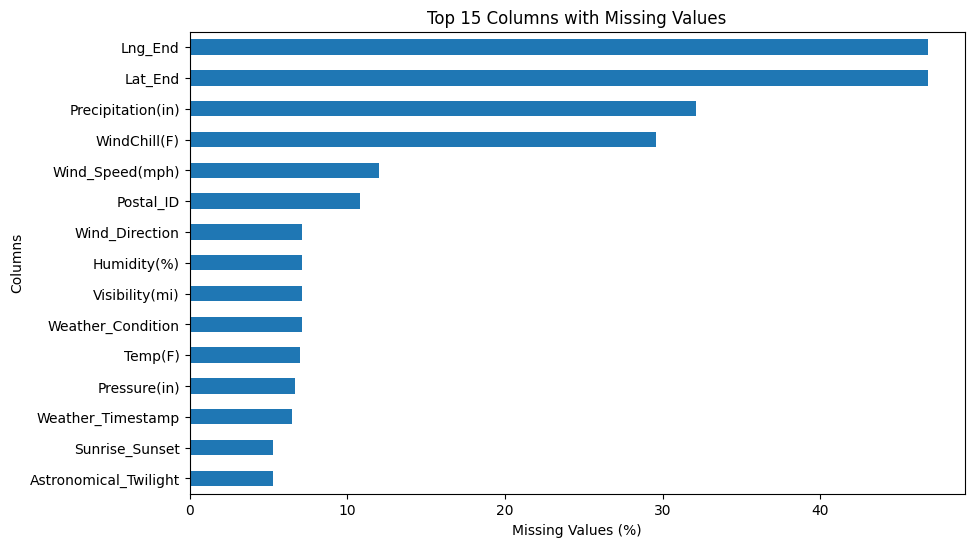

In [20]:
# Plot the percentage of missing values
plt.figure(
    figsize=(10, 6)
)

missing_df[
    'Missing_Percent'
].head(15).sort_values().plot(
    kind='barh'
)

plt.title(
    'Top 15 Columns with Missing Values'
)

plt.xlabel(
    'Missing Values (%)'
)

plt.ylabel(
    'Columns'
)

plt.show()

**Comment:** The largest missingness is in the ending GPS coordinates (`Lat_End` and `Lng_End`), at about 46.8%, followed by precipitation (~32.1%) and wind chill (~29.6%). These variables should not be dropped globally because they are not required for every analysis; instead, missing values can be excluded only when a specific figure needs those columns.


## Fix Data Types

In [21]:
# Convert Incident_Start to datetime
# format='mixed' handles different date formats
df['Incident_Start'] = pd.to_datetime(
    df['Incident_Start'],
    format='mixed',
    errors='coerce'
)

# Convert Incident_End to datetime
df['Incident_End'] = pd.to_datetime(
    df['Incident_End'],
    format='mixed',
    errors='coerce'
)

In [22]:
# Check the data types after conversion
df[
    [
        'Incident_Start',
        'Incident_End'
    ]
].dtypes

,0
Incident_Start,datetime64[ns]
Incident_End,datetime64[ns]


In [23]:
# Check missing dates after conversion
print(
    'Missing Incident_Start:',
    df['Incident_Start'].isna().sum()
)

print(
    'Missing Incident_End:',
    df['Incident_End'].isna().sum()
)

Missing Incident_Start: 0
Missing Incident_End: 0


## Create Time Features

In [24]:
# Extract year
df['Year'] = df[
    'Incident_Start'
].dt.year

# Extract month number
df['Month'] = df[
    'Incident_Start'
].dt.month

# Extract month name
df['Month_Name'] = df[
    'Incident_Start'
].dt.month_name()

# Extract day of week
df['Day_of_Week'] = df[
    'Incident_Start'
].dt.day_name()

# Extract accident hour
df['Hour'] = df[
    'Incident_Start'
].dt.hour

In [25]:
# Function to classify months into seasons
def get_season(month):

    if pd.isna(month):
        return np.nan

    if month in [12, 1, 2]:
        return 'Winter'

    elif month in [3, 4, 5]:
        return 'Spring'

    elif month in [6, 7, 8]:
        return 'Summer'

    else:
        return 'Fall'

In [26]:
# Create the Season column
df['Season'] = df[
    'Month'
].apply(
    get_season
)

In [27]:
# Function to classify each hour into a period of the day
def get_time_of_day(hour):

    if pd.isna(hour):
        return np.nan

    if 5 <= hour < 12:
        return 'Morning'

    elif 12 <= hour < 17:
        return 'Afternoon'

    elif 17 <= hour < 21:
        return 'Evening'

    else:
        return 'Night'

In [28]:
# Create Time_of_Day column
df['Time_of_Day'] = df[
    'Hour'
].apply(
    get_time_of_day
)

In [29]:
# Create a weekend indicator while preserving missing values
df['Is_Weekend'] = np.where(
    df['Day_of_Week'].isna(),
    np.nan,
    df['Day_of_Week'].isin([
        'Saturday',
        'Sunday'
    ])
)

In [30]:
# Preview the newly created time features
df[
    [
        'Incident_Start',
        'Year',
        'Month',
        'Month_Name',
        'Day_of_Week',
        'Hour',
        'Season',
        'Time_of_Day',
        'Is_Weekend'
    ]
].head()

,Incident_Start,Year,Month,Month_Name,Day_of_Week,Hour,Season,Time_of_Day,Is_Weekend
0,2021-02-02 22:37:00,2021,2,February,Tuesday,22,Winter,Night,0.0
1,2022-05-23 13:12:46,2022,5,May,Monday,13,Spring,Afternoon,0.0
2,2020-03-06 12:38:59,2020,3,March,Friday,12,Spring,Afternoon,0.0
3,2020-12-28 18:38:46,2020,12,December,Monday,18,Winter,Evening,0.0
4,2020-06-05 16:28:26,2020,6,June,Friday,16,Summer,Afternoon,0.0


## Standard EDA

In [31]:
# Count accidents by severity level
df[
    'Severity'
].value_counts().sort_index()

,count
Severity,
1.0,12739
2.0,1170029
3.0,246804
4.0,38823


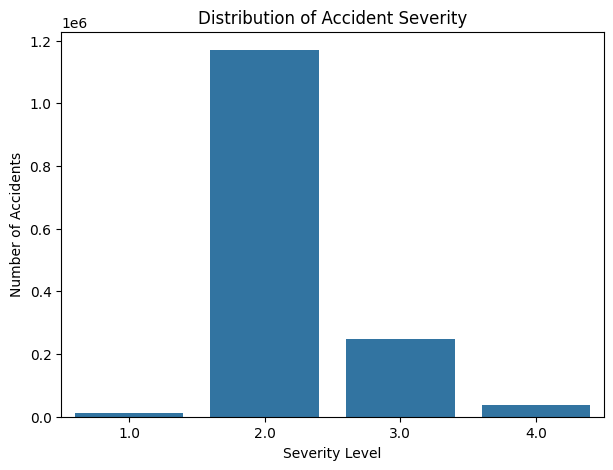

In [32]:
# Plot accident severity distribution
plt.figure(
    figsize=(7, 5)
)

sns.countplot(
    data=df,
    x='Severity',
    order=sorted(
        df['Severity'].dropna().unique()
    )
)

plt.title(
    'Distribution of Accident Severity'
)

plt.xlabel(
    'Severity Level'
)

plt.ylabel(
    'Number of Accidents'
)

plt.show()

**Comment:** Accident severity is highly concentrated in Severity 2, with 1,170,029 records. Severity 3 is the next most common, while Severity 1 and Severity 4 are much less frequent. This indicates that most recorded incidents are moderate rather than extremely severe.


### Accidents by Year

In [33]:
# Count accidents by year
year_counts = df[
    'Year'
].value_counts().sort_index()

year_counts

,count
Year,
2016,82071
2017,143634
2018,178368
2019,190852
2020,235858
2021,312711
2022,352976
2023,49209


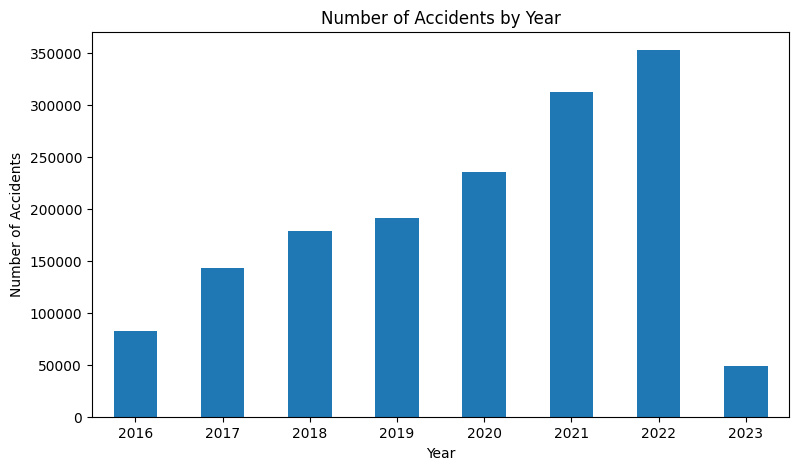

In [34]:
# Plot accidents by year
plt.figure(
    figsize=(9, 5)
)

year_counts.plot(
    kind='bar'
)

plt.title(
    'Number of Accidents by Year'
)

plt.xlabel(
    'Year'
)

plt.ylabel(
    'Number of Accidents'
)

plt.xticks(
    rotation=0
)

plt.show()

**Comment:** Accident records generally increase from 2016 through 2022, with 2022 having the highest count (352,976). The much lower count in 2023 should be interpreted cautiously because it may reflect incomplete or uneven data coverage rather than a true decline in accidents.


### Accidents by Month

In [35]:
# Define the correct month order
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

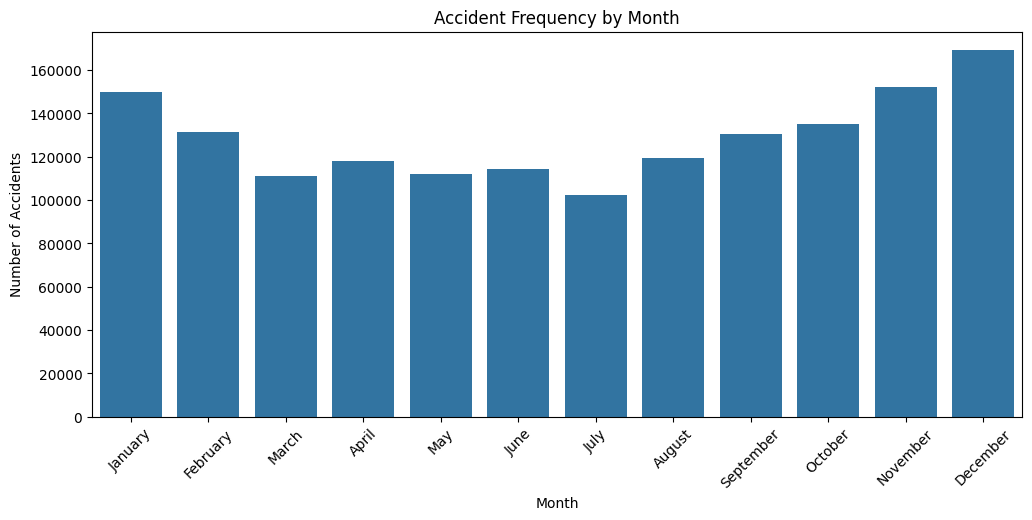

In [36]:
# Plot accident frequency by month
plt.figure(
    figsize=(12, 5)
)

sns.countplot(
    data=df,
    x='Month_Name',
    order=month_order
)

plt.title(
    'Accident Frequency by Month'
)

plt.xlabel(
    'Month'
)

plt.ylabel(
    'Number of Accidents'
)

plt.xticks(
    rotation=45
)

plt.show()

**Comment:** Accident frequency varies across the year. December has the highest number of recorded accidents, followed by November and January, while July has the lowest. This suggests a seasonal pattern, with more recorded incidents toward the end and beginning of the year.


### Accidents by Day of Week

In [37]:
# Define day order
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

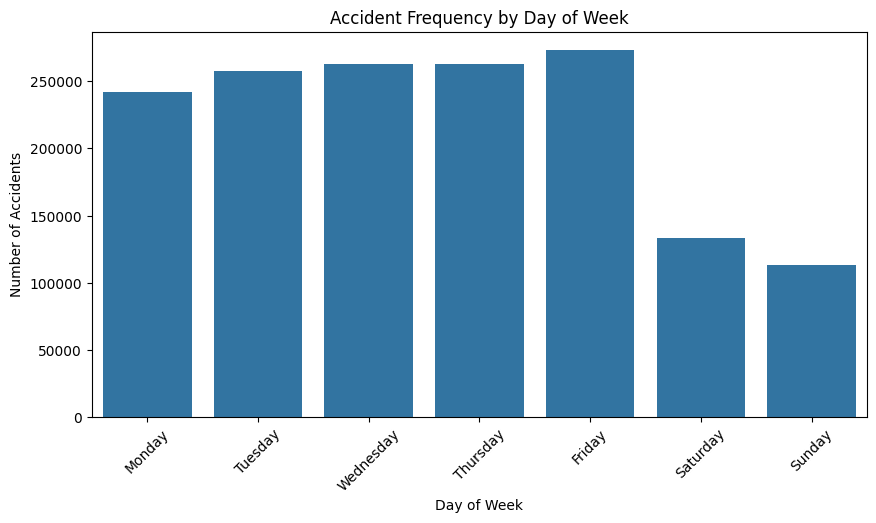

In [38]:
# Plot accident frequency by day of week
plt.figure(
    figsize=(10, 5)
)

sns.countplot(
    data=df,
    x='Day_of_Week',
    order=day_order
)

plt.title(
    'Accident Frequency by Day of Week'
)

plt.xlabel(
    'Day of Week'
)

plt.ylabel(
    'Number of Accidents'
)

plt.xticks(
    rotation=45
)

plt.show()

**Comment:** Weekdays have substantially more recorded accidents than weekends. Friday has the highest frequency, while Sunday has the lowest. This pattern is consistent with heavier weekday travel and commuting activity.


### Accidents by Hour

In [39]:
# Count accidents by hour
hour_counts = df[
    'Hour'
].value_counts().sort_index()

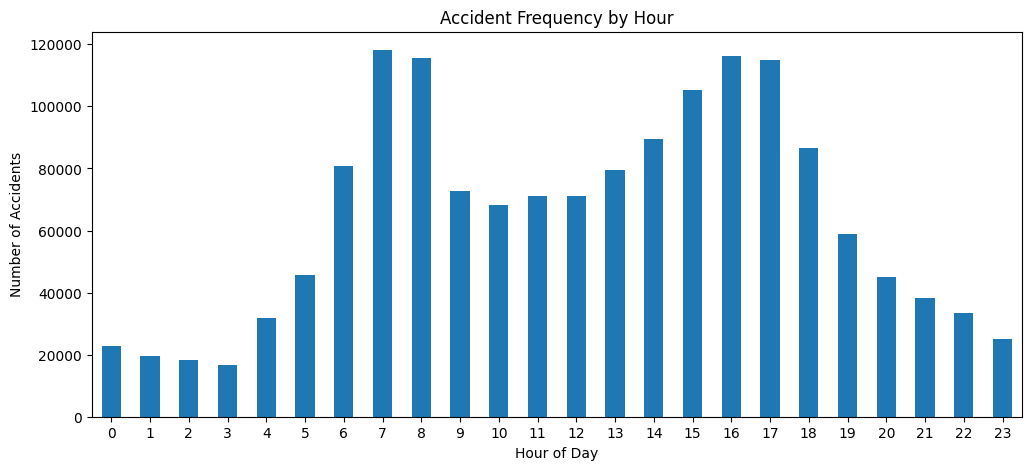

In [40]:
# Plot accidents by hour
plt.figure(
    figsize=(12, 5)
)

hour_counts.plot(
    kind='bar'
)

plt.title(
    'Accident Frequency by Hour'
)

plt.xlabel(
    'Hour of Day'
)

plt.ylabel(
    'Number of Accidents'
)

plt.xticks(
    rotation=0
)

plt.show()

**Comment:** The hourly pattern shows two clear high-risk periods: the morning commute around 7–8 AM and the afternoon commute around 4–5 PM. Overnight and very early morning hours have the fewest recorded accidents.


### Accidents by Time of Day

In [41]:
# Define time-of-day order
time_order = [
    'Morning',
    'Afternoon',
    'Evening',
    'Night'
]

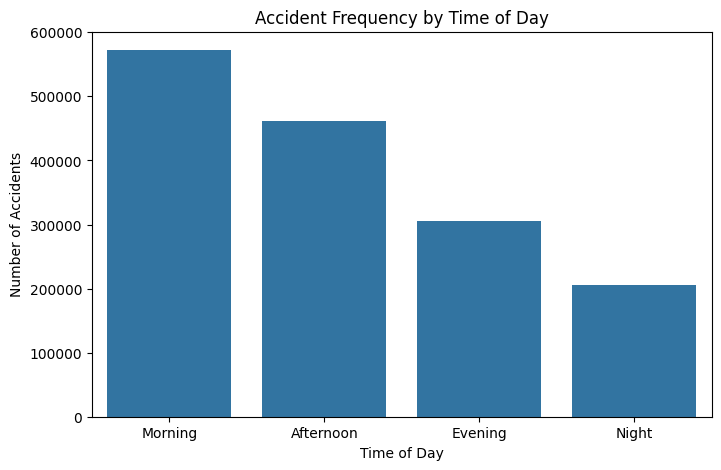

In [42]:
# Plot accident frequency by time of day
plt.figure(
    figsize=(8, 5)
)

sns.countplot(
    data=df,
    x='Time_of_Day',
    order=time_order
)

plt.title(
    'Accident Frequency by Time of Day'
)

plt.xlabel(
    'Time of Day'
)

plt.ylabel(
    'Number of Accidents'
)

plt.show()

**Comment:** Morning has the highest number of recorded accidents, followed by afternoon, evening, and night. This supports the hourly analysis and suggests that periods of heavier daytime traffic contribute strongly to accident frequency.


### Accidents by Season

In [43]:
# Define season order
season_order = [
    'Winter',
    'Spring',
    'Summer',
    'Fall'
]

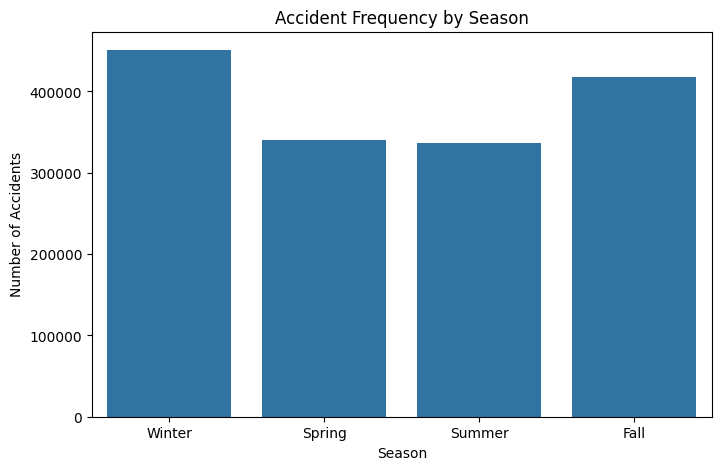

In [44]:
# Plot accident frequency by season
plt.figure(
    figsize=(8, 5)
)

sns.countplot(
    data=df,
    x='Season',
    order=season_order
)

plt.title(
    'Accident Frequency by Season'
)

plt.xlabel(
    'Season'
)

plt.ylabel(
    'Number of Accidents'
)

plt.show()

**Comment:** Winter has the highest accident frequency, followed by fall. Spring and summer have lower totals, with summer slightly lower than spring. This further supports the presence of seasonal variation in accident occurrence.


## Peak Accident Hours by Day

In [45]:
# Create a table of accident counts by day and hour
day_hour = pd.crosstab(
    df['Day_of_Week'],
    df['Hour']
)

# Reorder the days
day_hour = day_hour.reindex(
    day_order
)

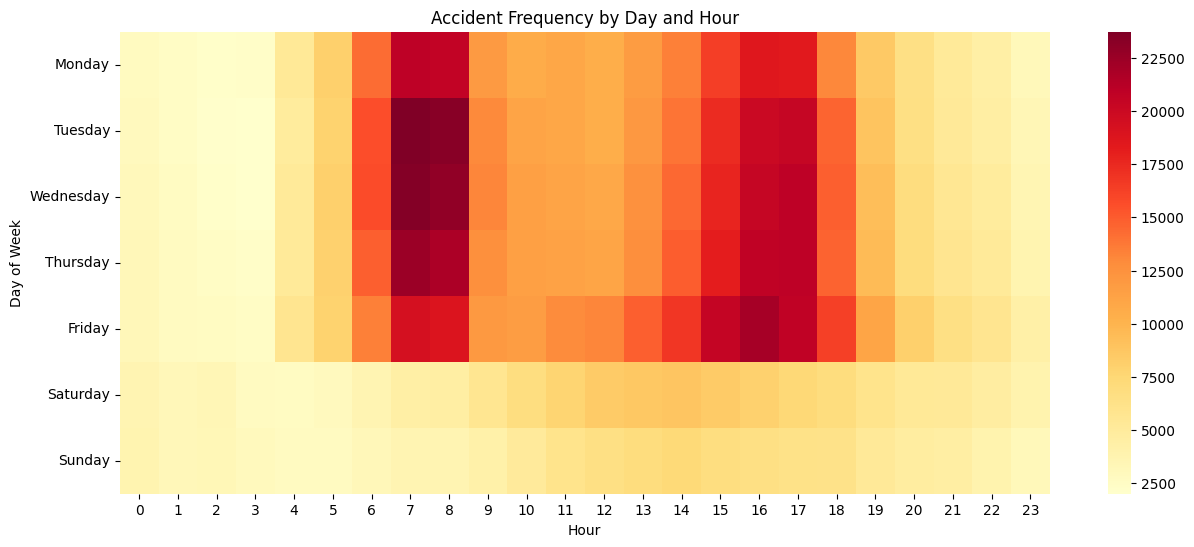

In [46]:
# Plot accident frequency by day and hour
plt.figure(
    figsize=(15, 6)
)

sns.heatmap(
    day_hour,
    cmap='YlOrRd'
)

plt.title(
    'Accident Frequency by Day and Hour'
)

plt.xlabel(
    'Hour'
)

plt.ylabel(
    'Day of Week'
)

plt.show()

**Comment:** The heatmap shows that peak accident hours depend on the day of the week. Weekdays show strong peaks around the morning commute (approximately 6–8 AM) and afternoon commute (approximately 3–5 PM), while weekends have lower and more evenly distributed accident counts.


## Day vs Night Severity

In [47]:
# Check available day/night categories
df[
    'Sunrise_Sunset'
].value_counts(
    dropna=False
)

,count
Sunrise_Sunset,
Day,1014669
Night,449312
NaN,81698


In [48]:
# Create a cross-tabulation between day/night and severity
day_night_severity = pd.crosstab(
    df['Sunrise_Sunset'],
    df['Severity']
)

day_night_severity

Severity,1.0,2.0,3.0,4.0
Sunrise_Sunset,,,,
Day,10434,804092,177492,22651
Night,2258,362158,69171,15725


In [49]:
# Calculate severity percentages within day and night
day_night_severity_percent = pd.crosstab(
    df['Sunrise_Sunset'],
    df['Severity'],
    normalize='index'
) * 100

day_night_severity_percent

Severity,1.0,2.0,3.0,4.0
Sunrise_Sunset,,,,
Day,1.028316,79.246730,17.492601,2.232354
Night,0.502546,80.602788,15.394870,3.499795


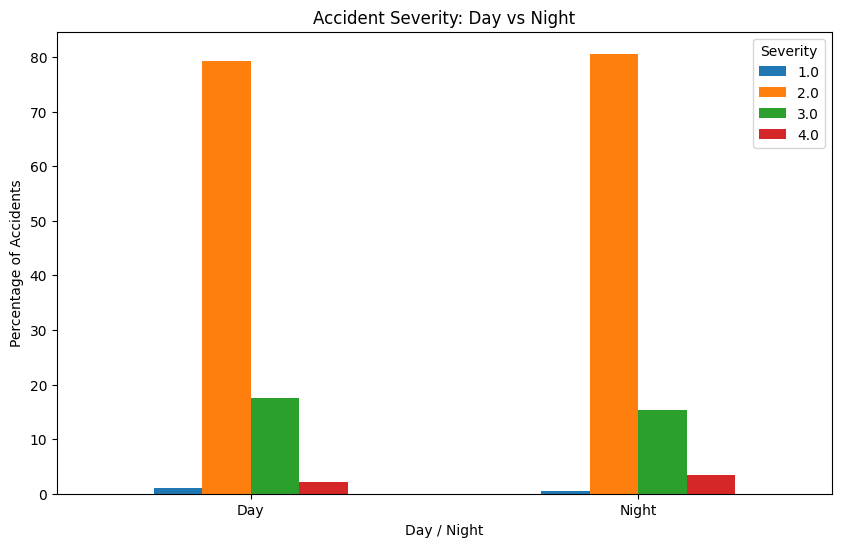

In [50]:
# Plot severity percentages for day and night
day_night_severity_percent.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title(
    'Accident Severity: Day vs Night'
)

plt.xlabel(
    'Day / Night'
)

plt.ylabel(
    'Percentage of Accidents'
)

plt.xticks(
    rotation=0
)

plt.legend(
    title='Severity'
)

plt.show()

**Comment:** Most accidents occur during the day, but the proportion of the most severe accidents is higher at night. Severity 4 represents about 3.50% of nighttime accidents compared with 2.23% during daytime. This suggests that nighttime accidents are less frequent overall but proportionally more severe.


## Cities and Regions

In [51]:
# Find the 10 cities with the highest number of accidents
top_cities = df[
    'City_name'
].value_counts().head(10)

top_cities

,count
City_name,
Miami,35405
Houston,32426
Los Angeles,29723
Charlotte,26363
Dallas,24700
Orlando,20799
Austin,18561
Raleigh,16263
Nashville,13892


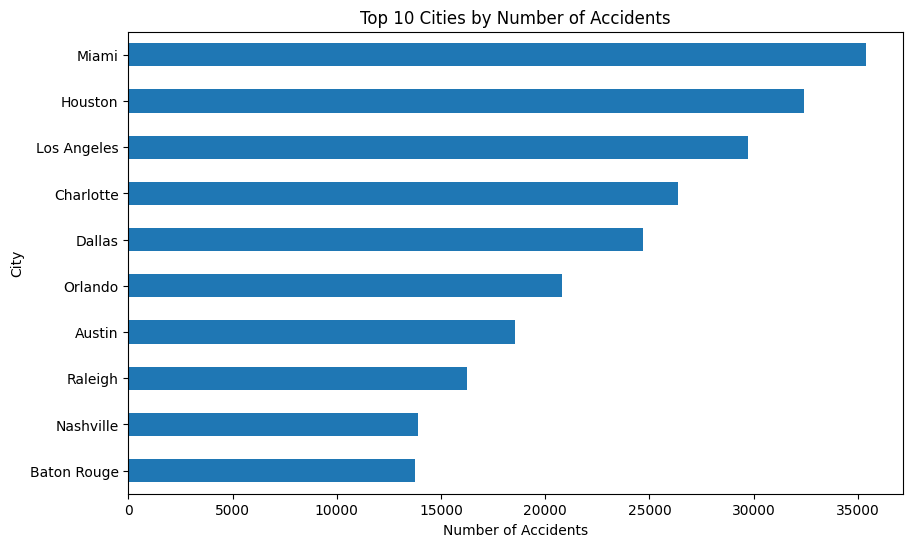

In [52]:
# Plot the top 10 cities by accident count
plt.figure(
    figsize=(10, 6)
)

top_cities.sort_values().plot(
    kind='barh'
)

plt.title(
    'Top 10 Cities by Number of Accidents'
)

plt.xlabel(
    'Number of Accidents'
)

plt.ylabel(
    'City'
)

plt.show()

**Comment:** Miami has the highest accident count among the top cities (35,405), followed by Houston (32,426) and Los Angeles (29,723). These cities represent important locations for targeted risk assessment and safety interventions.


In [53]:
# Find the states with the highest number of accidents
top_states = df[
    'State'
].value_counts().head(10)

top_states

,count
State,
CA,331378
FL,166633
TX,110701
SC,72708
NY,66119
NC,64254
VA,58052
PA,56258
MN,36513


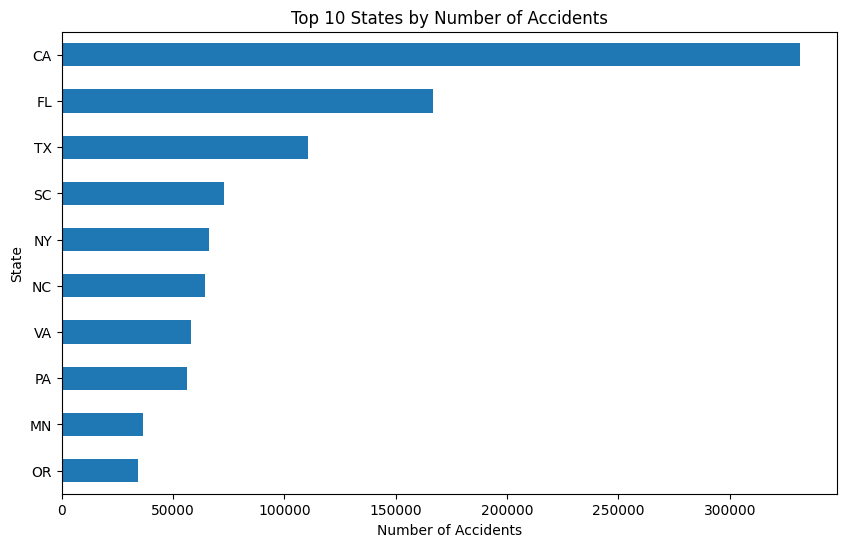

In [54]:
# Plot the top states by accident count
plt.figure(
    figsize=(10, 6)
)

top_states.sort_values().plot(
    kind='barh'
)

plt.title(
    'Top 10 States by Number of Accidents'
)

plt.xlabel(
    'Number of Accidents'
)

plt.ylabel(
    'State'
)

plt.show()

**Comment:** California has by far the highest number of recorded accidents (331,378), followed by Florida (166,633) and Texas (110,701). Because state populations, road networks, and dataset coverage differ, these counts show recorded accident concentration rather than a per-driver or per-mile risk rate.


## Severity by City

In [55]:
# Get names of the 10 cities with the most accidents
top_city_names = top_cities.index

# Filter the dataset to the top cities
top_city_data = df[
    df['City_name'].isin(
        top_city_names
    )
]

In [56]:
# Calculate the average severity for each top city
city_severity = top_city_data.groupby(
    'City_name'
)['Severity'].mean().sort_values(
    ascending=False
)

city_severity

,Severity
City_name,
Dallas,2.261660
Los Angeles,2.231134
Houston,2.183896
Nashville,2.145551
Miami,2.100268
Austin,2.092344
Raleigh,2.089774
Baton Rouge,2.081191
Orlando,2.066734


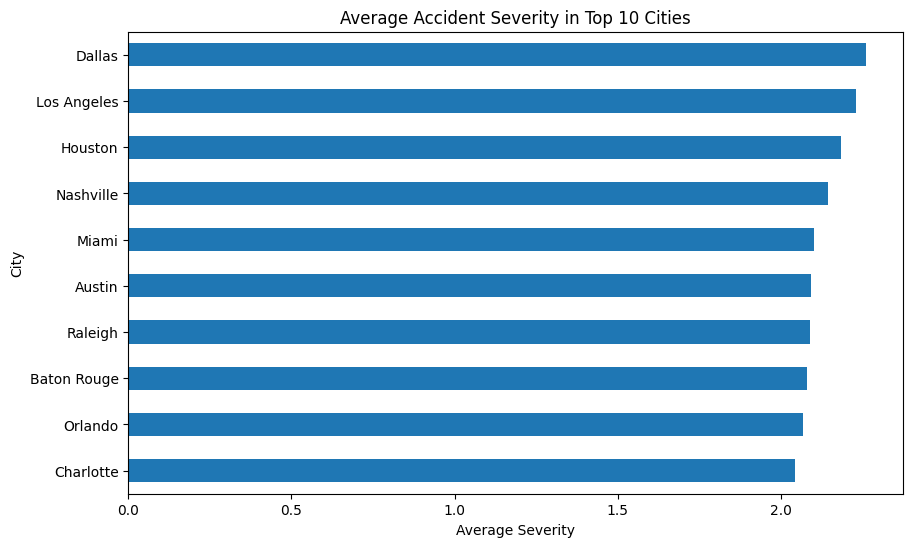

In [57]:
# Plot average severity by city
plt.figure(
    figsize=(10, 6)
)

city_severity.sort_values().plot(
    kind='barh'
)

plt.title(
    'Average Accident Severity in Top 10 Cities'
)

plt.xlabel(
    'Average Severity'
)

plt.ylabel(
    'City'
)

plt.show()

**Comment:** Among the 10 cities with the highest accident counts, Dallas has the highest average severity (2.26), followed by Los Angeles (2.23) and Houston (2.18). This shows that accident frequency and accident severity are not necessarily the same type of risk and should be evaluated separately.


## Weather EDA

In [58]:
# Find the 10 most common weather conditions during accidents
top_weather = df[
    'Weather_Condition'
].value_counts().head(10)

top_weather

,count
Weather_Condition,
Fair,486767
Mostly Cloudy,193196
Cloudy,155201
Clear,153613
Partly Cloudy,133004
Overcast,72487
Light Rain,66882
Scattered Clouds,38830
Light Snow,24376


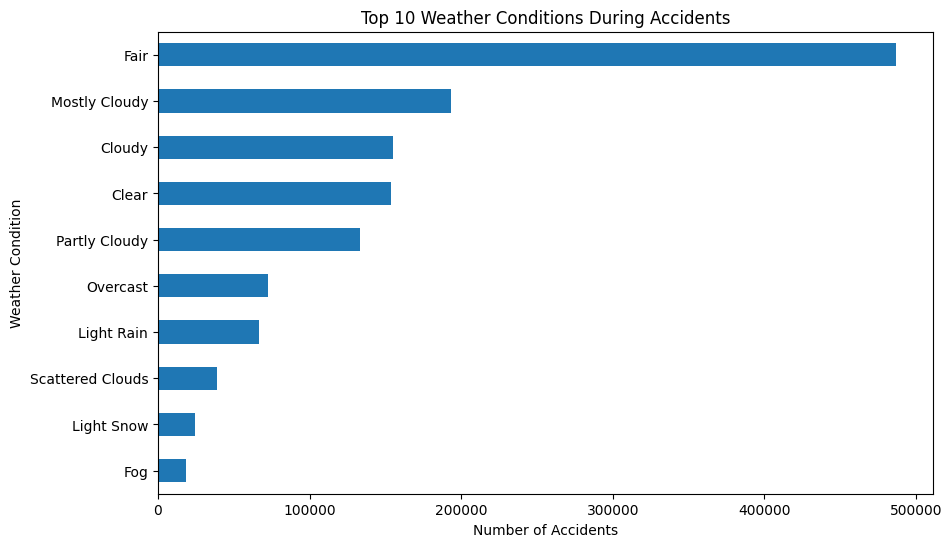

In [59]:
# Plot the most common weather conditions
plt.figure(
    figsize=(10, 6)
)

top_weather.sort_values().plot(
    kind='barh'
)

plt.title(
    'Top 10 Weather Conditions During Accidents'
)

plt.xlabel(
    'Number of Accidents'
)

plt.ylabel(
    'Weather Condition'
)

plt.show()

**Comment:** Most recorded accidents occur under common weather conditions such as Fair, Mostly Cloudy, Cloudy, and Clear. Fair weather alone accounts for 486,767 records. Therefore, accidents are not limited to severe weather; exposure and traffic volume likely also play an important role.


## Numerical Distributions

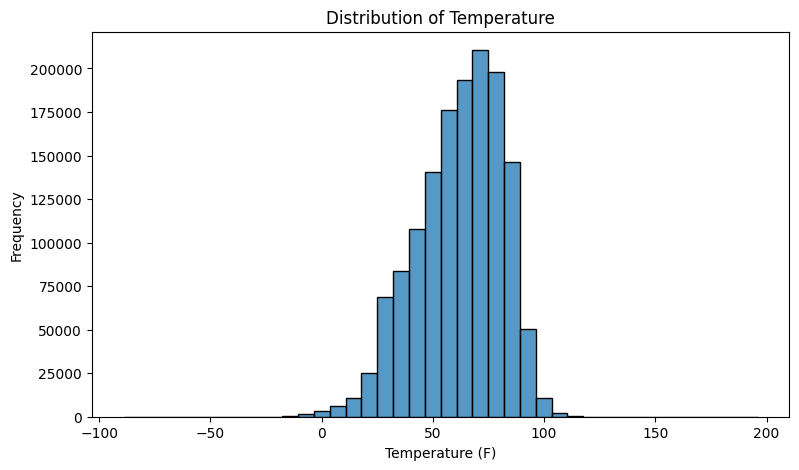

In [60]:
# Plot temperature distribution
plt.figure(
    figsize=(9, 5)
)

sns.histplot(
    data=df,
    x='Temp(F)',
    bins=40
)

plt.title(
    'Distribution of Temperature'
)

plt.xlabel(
    'Temperature (F)'
)

plt.ylabel(
    'Frequency'
)

plt.show()

**Comment:** Most accident records are associated with moderate temperatures, with the distribution concentrated roughly between 40°F and 90°F. Extreme temperatures occur much less frequently in the dataset, so temperature alone does not appear to define where most accidents occur.


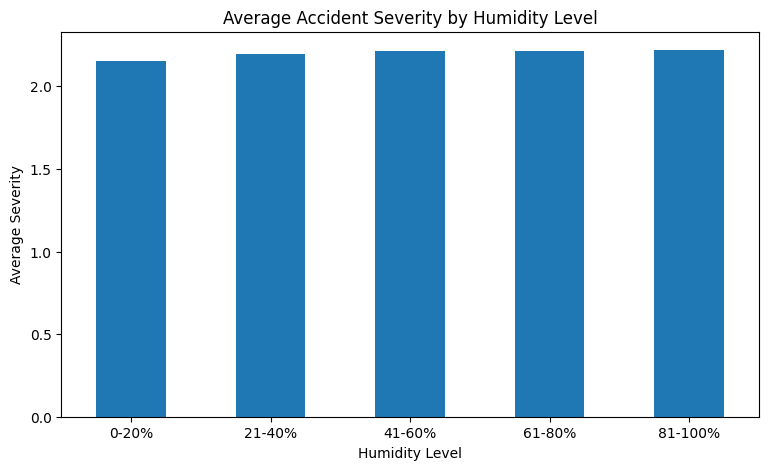

In [61]:
# Create humidity ranges to make the relationship easier to interpret
humidity_data = df[
    [
        'Humidity(%)',
        'Severity'
    ]
].dropna().copy()

humidity_data['Humidity_Range'] = pd.cut(
    humidity_data['Humidity(%)'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=[
        '0-20%',
        '21-40%',
        '41-60%',
        '61-80%',
        '81-100%'
    ],
    include_lowest=True
)

# Calculate the average accident severity within each humidity range
humidity_severity = humidity_data.groupby(
    'Humidity_Range',
    observed=False
)['Severity'].mean()

# Plot average severity by humidity range
plt.figure(
    figsize=(9, 5)
)

humidity_severity.plot(
    kind='bar'
)

plt.title(
    'Average Accident Severity by Humidity Level'
)

plt.xlabel(
    'Humidity Level'
)

plt.ylabel(
    'Average Severity'
)

plt.xticks(
    rotation=0
)

plt.show()


**Comment:** Average accident severity is very similar across all humidity ranges, staying close to Severity 2. The small differences between humidity groups suggest that humidity by itself has only a weak relationship with accident severity in this dataset.


## Accident Hotspots

In [62]:
# Select valid accident coordinates
location_data = df[
    [
        'Lat_Begin',
        'Lng_Begin'
    ]
].dropna()

In [63]:
# Use all available valid GPS coordinates for the density plot
# No random sampling is needed for the hexbin visualization


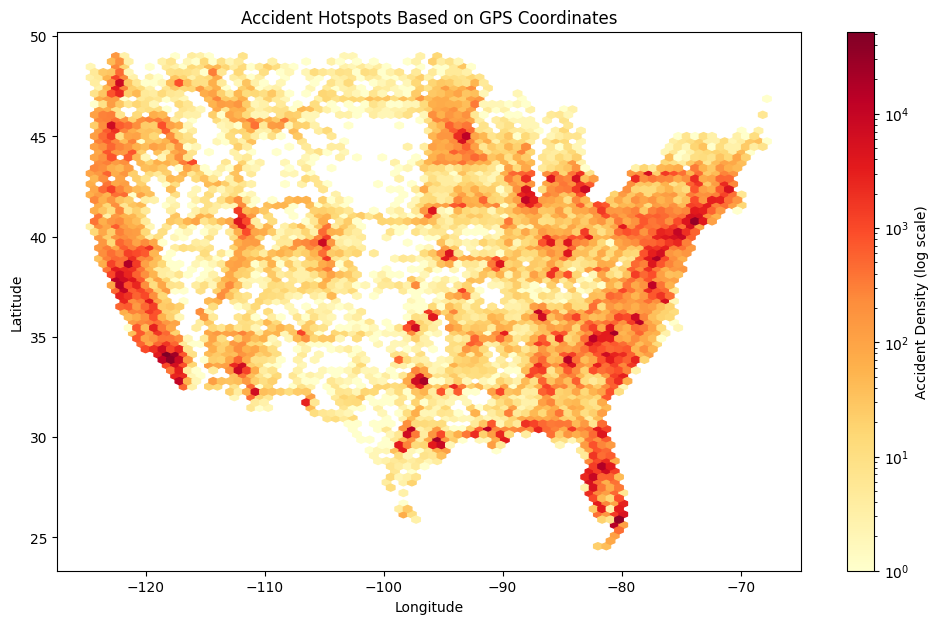

In [64]:
# Plot accident density using GPS coordinates
# Hexagonal bins show where accident records are concentrated geographically
plt.figure(
    figsize=(12, 7)
)

plt.hexbin(
    location_data['Lng_Begin'],
    location_data['Lat_Begin'],
    gridsize=80,
    mincnt=1,
    bins='log',
    cmap='YlOrRd'
)

plt.colorbar(
    label='Accident Density (log scale)'
)

plt.title(
    'Accident Hotspots Based on GPS Coordinates'
)

plt.xlabel(
    'Longitude'
)

plt.ylabel(
    'Latitude'
)

plt.show()


**Comment:** The GPS density map reveals clear accident hotspots rather than an even geographic distribution. High concentrations appear around major urban and highly populated road networks, especially across parts of the eastern and southeastern United States, Texas, and coastal California. These hotspots can support location-based underwriting and targeted safety campaigns.


## Correlation

In [65]:
# Select important numerical variables for correlation analysis
correlation_cols = [
    'Severity',
    'Temp(F)',
    'Humidity(%)',
    'Wind_Speed(mph)',
    'Precipitation(in)',
    'Distance(mi)',
    'Hour'
]

# Keep only columns available in the dataset
correlation_cols = [
    col
    for col in correlation_cols
    if col in df.columns
]

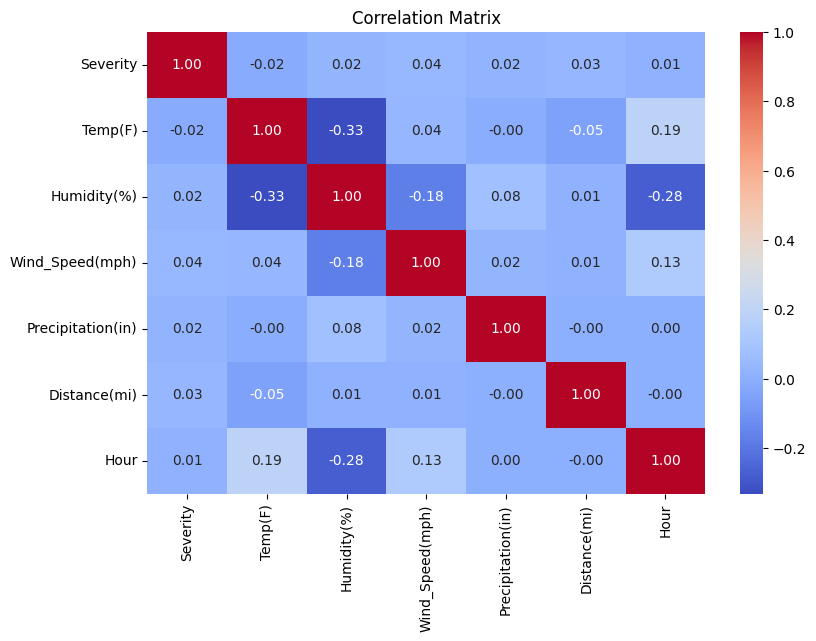

In [66]:
# Plot correlation heatmap
plt.figure(
    figsize=(9, 6)
)

sns.heatmap(
    df[
        correlation_cols
    ].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title(
    'Correlation Matrix'
)

plt.show()

**Comment:** Most numerical variables have weak correlations with accident severity, indicating that no single weather or time variable explains severity well on its own. The strongest visible relationships are between temperature and humidity (negative) and between humidity and hour of day (negative), while correlations with Severity remain close to zero.


## Final Check

In [67]:
# Display the final dataset dimensions
df.shape

(1545679, 54)

In [68]:
# Display the final column names
df.columns.tolist()

['Record_ID',
 'Data_Source',
 'Severity',
 'Incident_Start',
 'Incident_End',
 'Lat_Begin',
 'Lng_Begin',
 'Lat_End',
 'Lng_End',
 'Distance(mi)',
 'Event_Summary',
 'Street_name',
 'City_name',
 'County',
 'State',
 'Postal_ID',
 'Country_name',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Temp(F)',
 'WindChill(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Direction',
 'Wind_Speed(mph)',
 'Precipitation(in)',
 'Weather_Condition',
 'Amenity',
 'Bump',
 'Crossing',
 'Give_Way',
 'Road_Junction',
 'Dead_End',
 'Railway',
 'Roundabout',
 'Station',
 'Stop',
 'Traffic_Calming',
 'Traffic_Signal',
 'Turning_Loop',
 'Sunrise_Sunset',
 'Civil_Twilight',
 'Nautical_Twilight',
 'Astronomical_Twilight',
 'Year',
 'Month',
 'Month_Name',
 'Day_of_Week',
 'Hour',
 'Season',
 'Time_of_Day',
 'Is_Weekend']

In [69]:
# Preview the cleaned dataset
df.head()

,Record_ID,Data_Source,Severity,Incident_Start,Incident_End,Lat_Begin,Lng_Begin,Lat_End,Lng_End,Distance(mi),...,Nautical_Twilight,Astronomical_Twilight,Year,Month,Month_Name,Day_of_Week,Hour,Season,Time_of_Day,Is_Weekend
0,A-6572786,Source1,2.0,2021-02-02 22:37:00,2021-02-03 00:20:53,25.870425,-80.387858,25.891157,-80.388519,1.433,...,Night,Night,2021,2,February,Tuesday,22,Winter,Night,0.0
1,A-5294334,Source1,2.0,2022-05-23 13:12:46,2022-05-23 14:30:25,30.018366,-90.014456,30.020202,-90.014621,0.127,...,Day,Day,2022,5,May,Monday,13,Spring,Afternoon,0.0
2,A-7105054,Source1,3.0,2020-03-06 12:38:59,2020-03-06 13:08:55,39.669410,-104.829280,39.669410,-104.829280,0.000,...,Day,Day,2020,3,March,Friday,12,Spring,Afternoon,0.0
3,A-6947432,Source1,2.0,2020-12-28 18:38:46,2020-12-28 22:08:11,40.833765,-73.883218,40.835213,-73.882056,0.117,...,Night,Night,2020,12,December,Monday,18,Winter,Evening,0.0
4,A-7068416,Source1,1.0,2020-06-05 16:28:26,2020-06-05 17:13:26,32.337220,-111.012850,32.337220,-111.012850,0.000,...,Day,Day,2020,6,June,Friday,16,Summer,Afternoon,0.0


In [70]:
# Display final dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1545679 entries, 0 to 1545678
Data columns (total 54 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Record_ID              1545679 non-null  object        
 1   Data_Source            1468395 non-null  object        
 2   Severity               1468395 non-null  float64       
 3   Incident_Start         1545679 non-null  datetime64[ns]
 4   Incident_End           1545679 non-null  datetime64[ns]
 5   Lat_Begin              1468395 non-null  float64       
 6   Lng_Begin              1468395 non-null  float64       
 7   Lat_End                822436 non-null   float64       
 8   Lng_End                822436 non-null   float64       
 9   Distance(mi)           1468395 non-null  float64       
 10  Event_Summary          1468395 non-null  object        
 11  Street_name            1466264 non-null  object        
 12  City_name              14683

## Final Summary

After cleaning, the dataset contains **1,545,679 unique accident records**. Fully duplicated rows were removed, and duplicated `Record_ID` values were resolved by keeping the most complete record.

The EDA shows clear temporal and geographic patterns. Accident frequency is highest during **weekday commuting periods**, particularly around **7–8 AM** and **4–5 PM**. **Friday** has the highest accident frequency among the days of the week, while weekends have noticeably fewer records. At the seasonal level, **winter** has the highest number of recorded accidents, and **December** is the highest month.

Geographically, **California** has the highest recorded accident count, while **Miami, Houston, and Los Angeles** are the leading cities by frequency. GPS analysis also identifies clear accident hotspots, supporting location-based risk assessment.

Most accidents are classified as **Severity 2**. Although daytime accidents are more frequent, nighttime accidents are proportionally more severe: **Severity 4 represents about 3.50% of nighttime accidents compared with 2.23% during daytime**. Among the top 10 cities by accident count, **Dallas has the highest average severity (2.26)**.

Weather analysis shows that many accidents occur under normal conditions such as **Fair, Cloudy, and Clear weather**, so accident risk is not restricted to severe weather. Humidity shows only small differences in average severity across ranges, and the correlation analysis also indicates that individual weather variables have weak linear relationships with accident severity.

### Business Implications

These findings can support Guardian Insurance in **risk-based pricing**, **location-based underwriting**, and **targeted safety campaigns**. Higher-risk periods such as weekday commute hours and nighttime driving can receive additional attention, while geographic hotspots and high-frequency cities can be prioritized for more detailed risk monitoring.

### **Dataset Limitation**

The dataset does **not** contain a direct vehicle traffic-speed or speed-limit variable. `Wind_Speed(mph)` represents wind speed and should not be used as a substitute. Therefore, the relationship between vehicle speed, speed limits, and accident likelihood cannot be evaluated reliably using the available data.
